In [9]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Add two child directories
child_dir_1 = os.path.join(current_dir, "./state_space_models")
child_dir_2 = os.path.join(current_dir, "./gru_predictor")

for child_dir in [child_dir_1, child_dir_2]:
    if child_dir not in sys.path:
        sys.path.insert(0, child_dir)

print(f"Added to path: {current_dir}")
print(f"Added to path: {child_dir_1}")
print(f"Added to path: {child_dir_2}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\src\models_implementation_testing
Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\src\models_implementation_testing\./state_space_models
Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\src\models_implementation_testing\./gru_predictor


In [10]:
import pandas as pd
import numpy as np
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

def pick_random_file(df_seasonal, df_local, params=None, seed=42):
    """
    params: list of dicts, e.g.
        [
            {"name": "window_size", "value": 12, "comparator": ">="},
            {"name": "status", "value": "success", "comparator": "=="},
        ]
    seed: integer or None, forwarded to pandas.sample(random_state=seed)
    """
    if params is None or len(params) == 0:
        candidates = df_seasonal.copy()
    else:
        candidates =get_candidates(df_seasonal, params=params)

    if candidates.empty:
        raise ValueError("No rows match the given condition(s).")

    row = candidates.sample(1, random_state=seed).iloc[0]
    #print(row)
    
    filename = row["filename"]
    
    row_local = df_local[df_local['filename'] == filename].squeeze()
    #print(row_local)
    
    # union of all columns
    all_cols = row.index.union(row_local.index)
    
    cmp = pd.DataFrame(
        [
            row.reindex(all_cols),
            row_local.reindex(all_cols),
        ],
        index=["UC", "GRU"],
    )

    display(cmp.T)
        
    return filename



In [11]:
def _prepare_time_filtered_df(df, start_date=None, end_date=None):
    """Helper: ensure datetime and filter by dates."""
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df["timestamp_utc"]):
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)

        if start_date is not None:
            df = df[df["timestamp_utc"] >= start_date]
        if end_date is not None:
            df = df[df["timestamp_utc"] <= end_date]

    return df


def plot_water_meter_anomalies(
    df_actuals,
    df_actuals_with_gaps,
    df_predicted,
    df_predicted_2=None,
    model_1_label="Model 1",
    model_2_label="Model 2",
    figsize=(14, 8),
    title="Example of Daily + Weekly Fourier and GRU Predictions with 3σ Bands",
    start_date=None,
    end_date=None,
    save_path=None,
    use_robust_bands=False,
):
    """
    df_actuals:    columns timestamp_utc, Diff
    df_predicted:  columns timestamp_utc, predicted, residual,
                   is_anomaly_predicted, is_anomaly_actual,
                   upper_band, lower_band  (and optionally
                   upper_band_robust, lower_band_robust)
    df_predicted_2 (optional): same structure as df_predicted, for a second model
    model_1_label / model_2_label: legend labels for the two models
    use_robust_bands: if True, plot `upper_band_robust` / `lower_band_robust`
                     instead of `upper_band` / `lower_band`
    """

    # --- Colour palette ---
    COLOR_ACTUAL   = "#2E86AB"
    COLOR_MODEL_1  = "#A23B72"
    COLOR_BAND_1   = "#A23B72"
    COLOR_MODEL_2  = "#F18F01"
    COLOR_BAND_2   = "#E65C00"
    COLOR_ANOM_PRED = "#F18F01"
    COLOR_ANOM_ACT  = "#FF03CD"

    # Pick which band columns to use.
    if use_robust_bands:
        upper_col, lower_col = "upper_band_robust", "lower_band_robust"
    else:
        upper_col, lower_col = "upper_band", "lower_band"

    # --- Filter by date ---
    df_a  = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p1 = _prepare_time_filtered_df(df_predicted, start_date, end_date)
    df_p2 = (
        _prepare_time_filtered_df(df_predicted_2, start_date, end_date)
        if df_predicted_2 is not None else None
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    # --- Actuals ---
    ax.plot(
        df_a["timestamp_utc"],
        df_a["Diff"],
        color=COLOR_ACTUAL,
        linewidth=1,
        marker="None",
        markersize=1,
        zorder=3,
        alpha=0.9,
    )

    # --- Highlight points removed by UC resampling ---
    if df_actuals_with_gaps is not None:
        df_gaps_filtered = _prepare_time_filtered_df(df_actuals_with_gaps, start_date, end_date)

        pred_seg_start = df_gaps_filtered["timestamp_utc"].min()
        pred_seg_end   = df_gaps_filtered["timestamp_utc"].max()

        df_a_pred = df_a[
            (df_a["timestamp_utc"] >= pred_seg_start) &
            (df_a["timestamp_utc"] <= pred_seg_end)
        ]

        ax.plot(
            df_a_pred["timestamp_utc"],
            df_a_pred["Diff"],
            color=COLOR_ACTUAL,
            linewidth=2,
            marker="o",
            markersize=4,
            label="Actual (Diff)",
            zorder=3,
            alpha=0.9,
        )

        df_a_sorted = df_a.sort_values("timestamp_utc").reset_index(drop=True)
        df_gaps_sorted = df_gaps_filtered.sort_values("timestamp_utc").reset_index(drop=True)

        gaps_start = df_gaps_sorted["timestamp_utc"].min()
        gaps_end   = df_gaps_sorted["timestamp_utc"].max()
        df_a_in_gaps_range = df_a_sorted[
            (df_a_sorted["timestamp_utc"] >= gaps_start) &
            (df_a_sorted["timestamp_utc"] <= gaps_end)
        ].reset_index(drop=True)

        merged = pd.merge_asof(
            df_a_in_gaps_range,
            df_gaps_sorted[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_gaps"}),
            on="timestamp_utc",
            tolerance=pd.Timedelta("5min"),
            direction="nearest",
        )

        removed_mask = merged["Diff_gaps"].isna()
        df_removed = df_a_in_gaps_range[removed_mask]

        if len(df_removed) > 0:
            for pos in df_removed.index:
                neighbours = df_a_in_gaps_range.iloc[max(0, pos - 1) : pos + 2]
                ax.plot(
                    neighbours["timestamp_utc"],
                    neighbours["Diff"],
                    color="#E63946",
                    linewidth=2.5,
                    zorder=3,
                    alpha=0.9,
                )

            ax.scatter(
                df_removed["timestamp_utc"],
                df_removed["Diff"],
                color="#E63946",
                s=60,
                marker="o",
                zorder=4,
                label="Removed by UC resampling",
                edgecolors="#8B0000",
                linewidth=1.5,
            )

    # --- Helper: plot one model's prediction + band + anomalies ---
    def _plot_model(df_p, color_line, color_band, pred_label, band_label,
                    anom_zorder, pred_anom_marker="X"):
        if df_p is None or df_p.empty:
            return

        ax.plot(
            df_p["timestamp_utc"],
            df_p["predicted"],
            color=color_line,
            linewidth=2,
            marker="s",
            markersize=4,
            label=pred_label,
            zorder=2,
            alpha=0.8,
            linestyle="--",
        )

        # Detection bands now come from the predictions dataframe itself
        # (populated by build_results_df with save_detection_bands=True).
        if upper_col in df_p.columns and lower_col in df_p.columns:
            ax.plot(
                df_p["timestamp_utc"],
                df_p[upper_col],
                color=color_band,
                linestyle=":",
                linewidth=1.5,
                label=f"3σ band ({band_label})",
                zorder=1,
                alpha=0.6,
            )
            ax.plot(
                df_p["timestamp_utc"],
                df_p[lower_col],
                color=color_band,
                linestyle=":",
                linewidth=1.5,
                zorder=1,
                alpha=0.6,
            )

        if "is_anomaly_predicted" in df_p.columns:
            anomalies = df_p[df_p["is_anomaly_predicted"] == 1]
            if len(anomalies) > 0:
                ax.scatter(
                    anomalies["timestamp_utc"],
                    anomalies["actual"],
                    color=COLOR_ANOM_PRED,
                    s=150,
                    marker=pred_anom_marker,
                    label=f"Anomaly Predicted ({band_label})",
                    zorder=anom_zorder,
                    edgecolors="#C41E3A",
                    linewidth=2,
                )

        if "is_anomaly_actual" in df_p.columns:
            anomalies = df_p[df_p["is_anomaly_actual"] != 0]
            if len(anomalies) > 0:
                ax.scatter(
                    anomalies["timestamp_utc"],
                    anomalies["actual"],
                    color=COLOR_ANOM_ACT,
                    s=150,
                    marker="P",
                    label=f"Anomaly Actual ({band_label})",
                    zorder=anom_zorder + 1,
                    edgecolors="#C41E3A",
                    linewidth=2,
                )

    _plot_model(df_p1, COLOR_MODEL_1, COLOR_BAND_1,
                f"Predicted ({model_1_label})", model_1_label,
                anom_zorder=4, pred_anom_marker="X")
    _plot_model(df_p2, COLOR_MODEL_2, COLOR_BAND_2,
                f"Predicted ({model_2_label})", model_2_label,
                anom_zorder=5, pred_anom_marker="*")

    # --- Axis formatting ---
    ax.set_xlabel("Timestamp (UTC)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Water Consumption (Diff)", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=20)

    timestamps = []
    for d in filter(lambda x: x is not None and not x.empty, [df_a, df_p1, df_p2]):
        timestamps.append(d["timestamp_utc"].min())
        timestamps.append(d["timestamp_utc"].max())

    if timestamps:
        t_min, t_max = min(timestamps), max(timestamps)
        time_range = (t_max - t_min).total_seconds()
    else:
        time_range = 0

    if time_range < 3600:
        date_format, date_locator = "%H:%M:%S", mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format, date_locator = "%H:%M", mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format, date_locator = "%Y-%m-%d %H:%M", mdates.AutoDateLocator()
    else:
        date_format, date_locator = "%Y-%m-%d", mdates.AutoDateLocator()

    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=12, framealpha=0.95)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())

    return fig, ax

In [12]:
from pathlib import Path
from typing import List
import numpy as np
import pandas as pd
import pickle

# Extra columns for timing information
EXTRA_COLS = [
    "train_train_time_seconds",
    "second_train_time_seconds",
    "prediction_time_seconds",
    "number_of_anomalies",
    "number_of_anomalies_robust",
]

def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Returns only successful runs.
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df["status"] == "success"].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs from {csv_filepath}")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()

def extract_metrics(
    df: pd.DataFrame,
    include_non_zero_only: bool = False,
    unresampled: bool = False,
) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics and summary count metrics
    unresampled : bool
        If True, use unresampled_metric_* columns, otherwise metric_* columns
    """
    if unresampled:
        metric_cols = [col for col in df.columns if col.startswith("unresampled_metric_")]
        total_count_col = "unresampled_metric_total_count"
        non_zero_count_col = "unresampled_metric_non_zero_count"
        zero_count_col = "unresampled_metric_zero_count"
        non_zero_percentage_col = "unresampled_metric_non_zero_percentage"
    else:
        metric_cols = [col for col in df.columns if col.startswith("metric_")]
        total_count_col = "metric_total_count"
        non_zero_count_col = "metric_non_zero_count"
        zero_count_col = "metric_zero_count"
        non_zero_percentage_col = "metric_non_zero_percentage"

    if include_non_zero_only:
        metric_cols = [
            col
            for col in metric_cols
            if col.endswith("_nz")
            or col in [
                total_count_col,
                non_zero_count_col,
                zero_count_col,
                non_zero_percentage_col,
            ]
        ]

    return df[metric_cols]

def compute_metrics_summary(
    csv_filepaths: List[str],
    model_names: List[str] = None,
    include_non_zero_only: bool = False,
    only_converged: bool = True,
    verbose: bool = True,
    unresampled: bool = False,
    exclude_high_mae: bool = False,   # <-- new flag
    mae_threshold: float = 50.0,      # <-- optional parameter
) -> pd.DataFrame:
    """
    Compute mean, std and median of metrics across samples for each model.

    Important:
    Only considers filenames that are successful and converged in all models.
    Metric type is controlled by the unresampled flag.
    Optionally excludes files where (un)resampled_metric_mae > mae_threshold.
    """
    if not csv_filepaths:
        raise ValueError("No CSV files found")

    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(
            f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names"
        )

    model_data_metrics = {}
    model_data_full = {}
    all_metrics = set()
    successful_counts = {}
    per_model_filenames = {}
    per_model_filenames_all = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    # choose which MAE column to use
    mae_col = "unresampled_metric_mae" if unresampled else "metric_mae"

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)
        
        per_model_filenames_all[model_name] = set(df["filename"].dropna().unique())

        if only_converged:
            if "converged_train" not in df.columns or "converged_second" not in df.columns:
                raise ValueError(
                    f"Columns 'converged_train' and/or 'converged_second' not found in {filepath}"
                )
            df = df[
                (df["converged_train"] == True) &
                (df["converged_second"] == True)
            ].copy()

            if verbose:
                print(f"  {model_name}: filtered to {len(df)} converged runs")

        if "filename" not in df.columns:
            raise ValueError(f"'filename' column not found in {filepath}")

        # ---- NEW FILTER HERE ----
        if exclude_high_mae:
            if mae_col not in df.columns:
                raise ValueError(f"Column '{mae_col}' not found in {filepath}")
            before = len(df)
            df = df[df[mae_col] <= mae_threshold].copy()
            if verbose:
                removed = before - len(df)
                print(
                    f"  {model_name}: excluded {removed} rows with {mae_col} > {mae_threshold}"
                )
        # -------------------------

        per_model_filenames[model_name] = set(df["filename"].dropna().unique())
        model_data_full[model_name] = df

    if not per_model_filenames:
        raise ValueError("No models loaded")

    common_filenames = set.intersection(*per_model_filenames.values())
    
    #with open('./pickles/common_filenames.pkl', 'wb') as f:
    #    pickle.dump(common_filenames, f)
    
    common_filenames_all = set.intersection(*per_model_filenames_all.values())
    
    with open('../pickles/common_filenames_all.pkl', 'wb') as f:
        pickle.dump(common_filenames_all, f)

    if verbose:
        print("-" * 80)
        print(
            f"Common filenames across all models (successful + converged"
            f"{' + MAE filtered' if exclude_high_mae else ''}): {len(common_filenames)}"
        )

    # --- rest of your original function stays the same ---
    for model_name in model_names:
        df = model_data_full[model_name]
        df = df[df["filename"].isin(common_filenames)].copy()

        if len(df) > 0:
            metrics_df = extract_metrics(
                df,
                include_non_zero_only=include_non_zero_only,
                unresampled=unresampled,
            )
            model_data_metrics[model_name] = metrics_df
            model_data_full[model_name] = df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)

            if verbose:
                print(f"  {model_name}: {len(metrics_df)} rows after filename intersection")
        else:
            model_data_metrics[model_name] = None
            model_data_full[model_name] = None
            successful_counts[model_name] = 0

            if verbose:
                print(f"  {model_name}: 0 rows after filename intersection")

    if verbose:
        print("-" * 80)

    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {"Metric": metric}

        for model_name in model_names:
            if model_data_metrics[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                metrics_df = model_data_metrics[model_name]
                if metric in metrics_df.columns:
                    series = metrics_df[metric]
                    row_data[f"{model_name}_Mean"] = series.mean()
                    row_data[f"{model_name}_Std"] = series.std()
                    row_data[f"{model_name}_Median"] = series.median()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan
                    row_data[f"{model_name}_Median"] = np.nan

        summary_rows.append(row_data)

    for time_col in EXTRA_COLS:
        row_data = {"Metric": time_col}

        for model_name in model_names:
            df_full = model_data_full.get(model_name)
            if df_full is None or time_col not in df_full.columns:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                series = df_full[time_col]
                row_data[f"{model_name}_Mean"] = series.mean()
                row_data[f"{model_name}_Std"] = series.std()
                row_data[f"{model_name}_Median"] = series.median()

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    summary_df.attrs["model_names"] = model_names
    summary_df.attrs["successful_counts"] = successful_counts
    summary_df.attrs["include_non_zero_only"] = include_non_zero_only
    summary_df.attrs["only_converged"] = only_converged
    summary_df.attrs["unresampled"] = unresampled
    summary_df.attrs["common_filenames_count"] = len(common_filenames)

    return summary_df

def format_metrics_table(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    decimal_places: int = 4,
    include_non_zero_only: bool = False,
) -> pd.DataFrame:
    """
    Format metrics summary table as 'mean ± std | median' for display.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "")
                        .replace("_Std", "")
                        .replace("_Median", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    df_display = summary_df.copy()

    if include_non_zero_only:
        df_display = df_display[
            df_display["Metric"].str.contains(
                "_nz|total_count|non_zero_count|non_zero_percentage", na=False
            )
            | df_display["Metric"].isin(EXTRA_COLS)
        ].copy()

    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {"Metric": row["Metric"]}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"
            median_col = f"{model_name}_Median"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)
            median_val = row.get(median_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val) and pd.notna(median_val):
                formatted_row[model_name] = (
                    f"{mean_val:.{decimal_places}f} ± "
                    f"{std_val:.{decimal_places}f} | "
                    f"{median_val:.{decimal_places}f}"
                )
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)

def display_metrics(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    show_all: bool = False,
    decimal_places: int = 4,
) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    formatted = format_metrics_table(
        summary_df,
        model_names,
        decimal_places,
        include_non_zero_only=not show_all,
    )

    metric_mode = "unresampled" if summary_df.attrs.get("unresampled", False) else "regular"

    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Metric type: {metric_mode}")
    print(f"Models: {', '.join(model_names)}")

    if "common_filenames_count" in summary_df.attrs:
        print(f"Common filenames in all models: {summary_df.attrs['common_filenames_count']}")

    if "successful_counts" in summary_df.attrs:
        counts = summary_df.attrs["successful_counts"]
        for m in model_names:
            print(f"  {m}: {counts[m]} rows after common filename filtering")

    print()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", None)

    return formatted

def get_metric_comparison(
    summary_df: pd.DataFrame,
    metric_name: str,
    model_names: List[str] = None,
) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    metric_row = summary_df[summary_df["Metric"] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df["Metric"].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{"Metric": metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)

def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.
    """
    metrics = sorted(summary_df["Metric"].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")
        
def display_selected_metrics(
    summary_df: pd.DataFrame,
    metrics: List[str],
    model_names: List[str] = None,
    decimal_places: int = 4,
) -> pd.DataFrame:
    """
    Display only the specified metrics from the summary table.
    """
    if model_names is None:
        model_names = summary_df.attrs.get("model_names", [
            col.replace("_Mean", "").replace("_Std", "").replace("_Median", "")
            for col in summary_df.columns if col != "Metric"
        ])
        model_names = list(dict.fromkeys(model_names))  # deduplicate, preserve order

    filtered = summary_df[summary_df["Metric"].isin(metrics)].copy()

    missing = [m for m in metrics if m not in summary_df["Metric"].values]
    if missing:
        print(f"⚠ Metrics not found: {missing}")

    # Reorder rows to match the requested order
    filtered["_order"] = filtered["Metric"].map({m: i for i, m in enumerate(metrics)})
    filtered = filtered.sort_values("_order").drop(columns="_order")

    formatted = format_metrics_table(filtered, model_names, decimal_places, include_non_zero_only=False)
    return formatted

In [13]:
def plot_confusion_matrices_clean(
    csv_files: list[str],
    model_names: list[str] | None = None,
    only_converged: bool = True,
    output_path: str = "confusion_matrices_clean.png",
) -> None:
    """
    Renders clean confusion matrices (z-score only) for all models.
    No heatmap — plain cells with percentage in centre and TP/FN/FP/TN
    label in the upper-right corner of each cell.

    Layout: one row per model, axis labels show Actual / Predicted classes,
    and P / R / F1 are shown below each matrix.
    """
    from pathlib import Path
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    if model_names is None:
        model_names = [Path(p).stem for p in csv_files]
    assert len(model_names) == len(csv_files)

    # ── 1. Load DataFrames ─────────────────────────────────────────────────
    dfs: dict[str, pd.DataFrame] = {}
    for name, path in zip(model_names, csv_files):
        df = pd.read_csv(path).set_index("filename")
        dfs[name] = df

    # ── 2. Common sensor set ───────────────────────────────────────────────
    if only_converged:
        usable_per_model = []
        for df in dfs.values():
            mask = (
                (df["status"] == "success")
                & (df["converged_train"] == True)
                & (df["converged_second"] == True)
            )
            usable_per_model.append(set(df.index[mask]))
        common_sensors = set.intersection(*usable_per_model)
    else:
        common_sensors = set.intersection(
            *[set(df.index[df["status"] == "success"]) for df in dfs.values()]
        )

    n_models = len(model_names)

    # ── 3. Draw one matrix per model ───────────────────────────────────────
    fig, axes = plt.subplots(
        1, n_models,
        figsize=(3.6 * n_models, 4.2),
        squeeze=False,
    )
    fig.suptitle("Confusion Matrices (Z-Score)", fontsize=14, fontweight="bold", y=1.02)

    row_labels = ["Actual\nanomalous", "Actual\nnormal"]
    col_labels = ["Predicted\nanomalous", "Predicted\nnormal"]
    corner_labels = [["TP", "FN"], ["FP", "TN"]]

    # Cell colours: diagonal = light green, off-diagonal = light red
    cell_colors = [
        ["#d4edda", "#f8d7da"],   # row 0: TP green, FN red
        ["#f8d7da", "#d4edda"],   # row 1: FP red, TN green
    ]
    text_colors = [
        ["#155724", "#721c24"],
        ["#721c24", "#155724"],
    ]

    for col_idx, (name, df) in enumerate(dfs.items()):
        ax = axes[0][col_idx]
        subset = df.loc[df.index.isin(common_sensors)]

        tp = int(subset["metric_pred_tp"].sum())
        tn = int(subset["metric_pred_tn"].sum())
        fp = int(subset["metric_pred_fp"].sum())
        fn = int(subset["metric_pred_fn"].sum())

        cm = np.array([[tp, fn],
                       [fp, tn]])
        total = cm.sum()

        ax.set_xlim(0, 2)
        ax.set_ylim(0, 2)
        ax.set_aspect("equal")
        ax.axis("off")

        # ── Draw cells ────────────────────────────────────────────────────
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                pct   = 100.0 * count / total if total > 0 else 0.0

                # Cell rectangle (row 0 = top, so y = 1 - i)
                rect = mpatches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04),
                    0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    linewidth=1.2,
                    edgecolor="#aaaaaa",
                    facecolor=cell_colors[i][j],
                )
                ax.add_patch(rect)

                # Percentage — centre of cell
                ax.text(
                    j + 0.5, 1 - i + 0.5,
                    f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color=text_colors[i][j],
                )
                
                # Count — below percentage in gray
                ax.text(
                    j + 0.5, 1 - i + 0.32,
                    f"({count:,})",
                    ha="center", va="center",
                    fontsize=10, color="#777777",
                )

                # TP/FN/FP/TN label — upper-right corner
                ax.text(
                    j + 0.93, 1 - i + 0.93,
                    corner_labels[i][j],
                    ha="right", va="top",
                    fontsize=12, color="#555555",
                    fontstyle="italic",
                )

        # ── Row labels (left side) ─────────────────────────────────────────
        for i, label in enumerate(row_labels):
            ax.text(
                -0.06, 1 - i + 0.5,
                label,
                ha="right", va="center",
                fontsize=12, color="#333333",
            )

        # ── Column labels (top) ────────────────────────────────────────────
        for j, label in enumerate(col_labels):
            ax.text(
                j + 0.5, 2.06,  # was 2.08
                label,
                ha="center", va="bottom",
                fontsize=12, color="#333333",
            )

        # ── Grid lines between cells ───────────────────────────────────────
        for v in [1]:
            ax.plot([0, 2], [v, v], color="#aaaaaa", lw=0.8)
            ax.plot([v, v], [0, 2], color="#aaaaaa", lw=0.8)

        # ── Metrics below matrix ───────────────────────────────────────────
        precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        f1 = (2 * precision * recall / (precision + recall)
              if not (np.isnan(precision) or np.isnan(recall)) and (precision + recall) > 0
              else float("nan"))

        ax.text(
            1.0, -0.18,
            f"P = {precision:.3f} | R = {recall:.3f} | F1 = {f1:.3f}",
            ha="center", va="top",
            fontsize=10, color="#333333",
        )

        # ── Model name as subplot title ────────────────────────────────────
        ax.set_title(name, fontsize=13, fontweight="bold", pad=50)  # was pad=18

    fig.tight_layout()
    plt.show()

In [27]:
df_metrics_seasonal = pd.read_csv('./state_space_models/results/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv')
df_metrics_weekly = pd.read_csv('./gru_predictor/results/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv')

#filename = pick_random_file(
#    df_metrics_seasonal,
#    df_metrics_weekly,
#    params=[
#        {"name": "converged_train", "value": True, "comparator": "=="},
#        {"name": "converged_second", "value": True, "comparator": "=="},
#        {"name": "status", "value": "success", "comparator": "=="},
#        {"name": "unresampled_metric_mape", "value": 1, "comparator": "<"},
#    ],
#    seed=87,
#)
meter_id = 131493
#131493 - nice vikend
#94592 - periodic hills
#121196 - nice ale chybi data
#90986 - big spikes, chybi data
#106555 - stoupajici diff
#58425 - mala perioda (unconverged train but second yes - long seasonal train time, 10min period, small gopt)
#144433 - same as above just enogh data but random spikes



#137402 - normal one, big acf1 on non seasonal
#131493 - big acf1 even seasonal
#106555 - stoupajici diff
#58425 - unconverged train but second yes - long seasonal train time, 10min period, small gopt
#108627 - converged local, unconverged seasonal, not enough data
#141674 - both unconverged - flat
#131721 - both unconverged - not flat, small gopt

In [28]:
print(meter_id)

131493


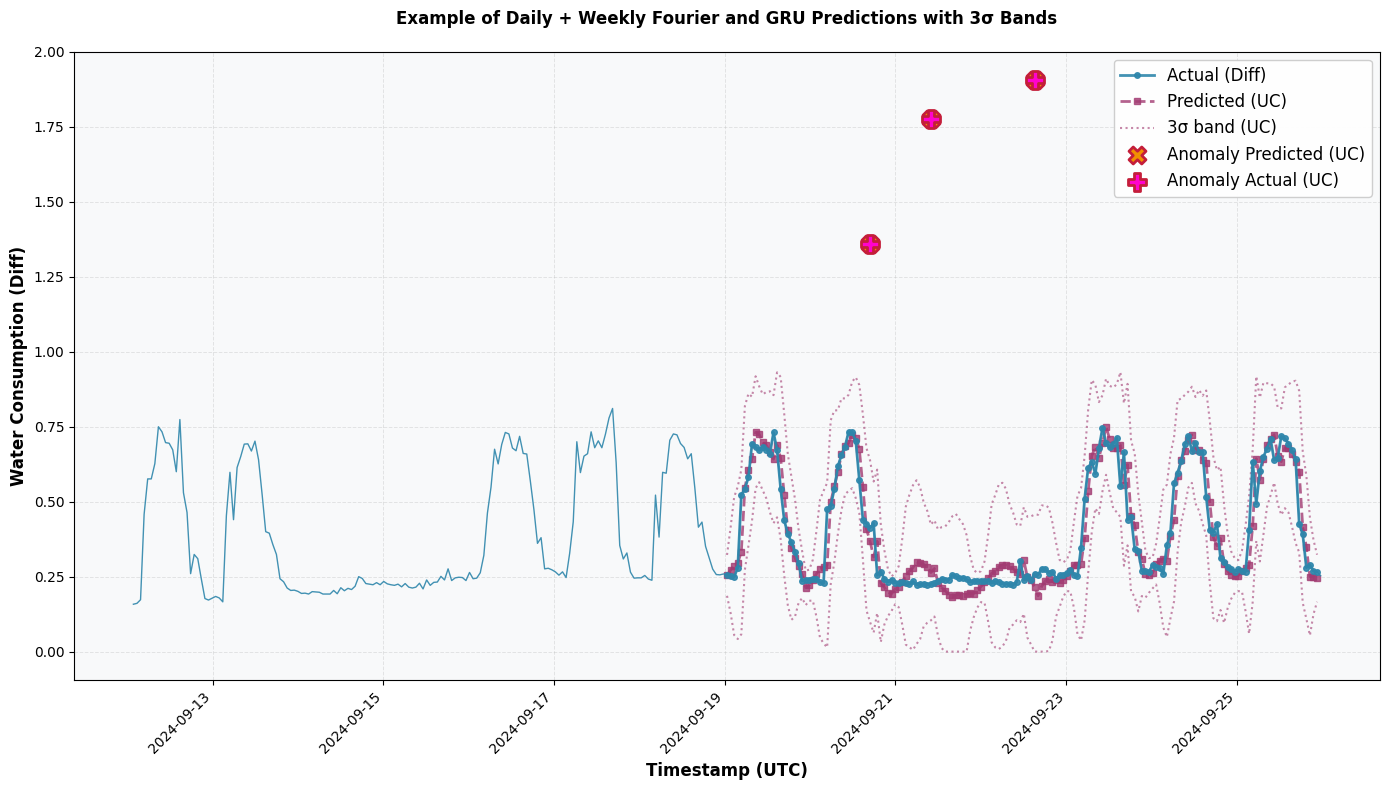

In [29]:
from local_level_unobserved_components_next_one_step_pred import process_single_meter
result = process_single_meter(f'../../data/sensor_data/{meter_id}.csv', save_detection_bands=True, predictions_output_csv='./test_pred_uc.csv')
ref_mean = result['ref_mean']
ref_std = result['ref_std']

df_predicted = pd.read_csv('./test_pred_uc.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

from run_gru_one_step_predict import process_single_meter
result2 = process_single_meter(f'../../data/sensor_data/{meter_id}.csv', predictions_output_csv='./test_pred_gru.csv')
ref_mean2 = result2['ref_mean']
ref_std2 = result2['ref_std']

df_predicted2 = pd.read_csv('./test_pred_gru.csv')
df_predicted2['timestamp_utc'] = pd.to_datetime(df_predicted2['timestamp_utc'])

df_raw = pd.read_csv(f'../../data/sensor_data/{meter_id}.csv')
df_raw['timestamp_utc'] = pd.to_datetime(df_raw['timestamp_utc'])

pred_start = df_predicted2['timestamp_utc'].min()
pred_end   = df_predicted2['timestamp_utc'].max()
window_start = pred_start - pd.Timedelta(weeks=5)

df_actuals = df_raw[
    (df_raw['timestamp_utc'] >= window_start) &
    (df_raw['timestamp_utc'] <= pred_end)
][['timestamp_utc', 'Diff']].reset_index(drop=True)

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals, df_actuals_with_gaps=df_actuals_with_gaps, df_predicted=df_predicted, model_1_label="UC",
                                        start_date=df_actuals['timestamp_utc'].iloc[0] + pd.Timedelta(weeks=4),
                                        end_date=df_actuals['timestamp_utc'].iloc[-1])

#fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals, df_actuals_with_gaps=df_actuals_with_gaps, df_predicted=df_predicted, ref_mean=ref_mean, ref_std=ref_std, model_1_label="UC",
#                                        df_predicted_2=None, ref_mean_2=None, ref_std_2=None, model_2_label=None,
#                                        start_date=df_actuals['timestamp_utc'].iloc[0] + pd.Timedelta(weeks=4),
#                                        end_date=df_actuals['timestamp_utc'].iloc[-1])

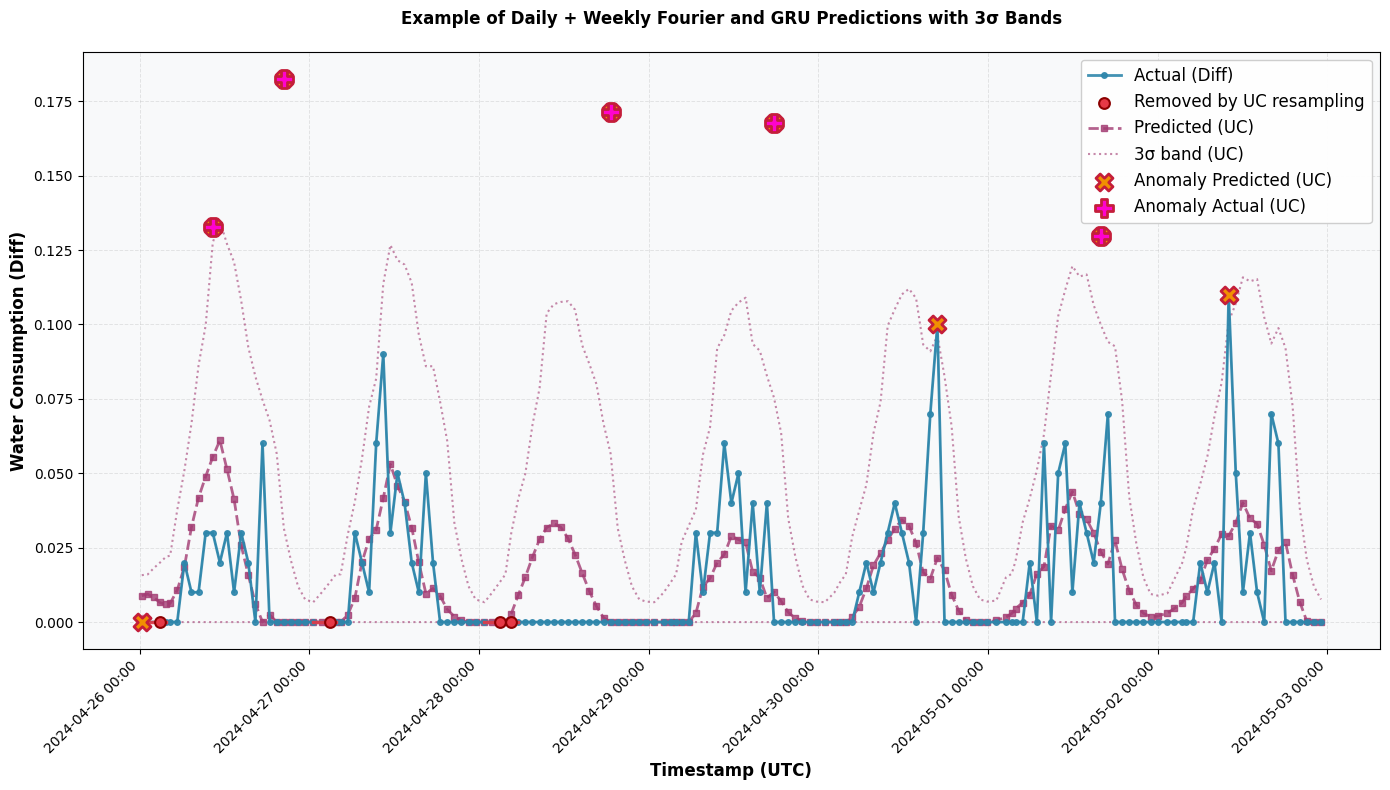

In [17]:
fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals, df_actuals_with_gaps=df_actuals_with_gaps, df_predicted=df_predicted, model_1_label="UC",
                                        start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0],
                                        end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1])

In [18]:
def plot_two_histograms_with_stats(
    df1,
    df2,
    metric,
    bins='auto',
    density=False,
    x_range=None,
    title1='UC',
    title2='GRU'
):
    """
    Plot two histograms in one figure and display a combined stats box.
    Remaining params are shared.
    """
    
    if metric not in df1.columns or metric not in df2.columns:
        print("Incorrect metric name.")
        
    values1 = df1[metric]
    values2 = df2[metric]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    fig.suptitle(metric, fontsize=14)

    # Combined range
    min_val = min(np.min(values1), np.min(values2))
    max_val = max(np.max(values1), np.max(values2))

    if x_range is None:
        x_range = (min_val, max_val)

    def _add_hist_with_stats(ax, values, title):
        # Histogram
        ax.hist(values, bins=bins, density=density,
                range=x_range, color='skyblue', edgecolor='black')
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

        # Stats
        min_v = np.min(values)
        max_v = np.max(values)
        median_v = np.median(values.dropna())
        mean_v = np.mean(values)
        std_v = np.std(values)

        stats_lines = [
            f"Min: {min_v:.2f}",
            f"Max: {max_v:.2f}",
            f"Median: {median_v:.2f}",
            f"Mean: {mean_v:.2f}",
            f"Std: {std_v:.2f}",
        ]
        stats_text = "\n".join(stats_lines)

        font_size = max(10, min(10, 10 - len(stats_lines) // 2))

        ax.text(
            0.02, 0.98, stats_text,
            transform=ax.transAxes,
            va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=font_size,
        )

    _add_hist_with_stats(ax1, values1, title1)
    _add_hist_with_stats(ax2, values2, title2)

    plt.tight_layout()
    plt.show()


In [19]:
#pd.concat([pd.read_csv(f) for f in ["./state_space_models/results/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv",
#                                    "./state_space_models/results/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test.csv"]],
#                                    ignore_index=True).to_csv("./state_space_models/results/merged_final_thesis.csv", index=False)
#
#pd.concat([pd.read_csv(f) for f in ['./gru_predictor/results/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv',
#                                    './gru_predictor/results/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_test.csv']],
#                                    ignore_index=True).to_csv("./gru_predictor/results/merged_final_thesis.csv", index=False)

summary_df_uc = pd.read_csv("./state_space_models/results/merged_final_thesis.csv")
summary_df_gru = pd.read_csv("./gru_predictor/results/merged_final_thesis.csv")


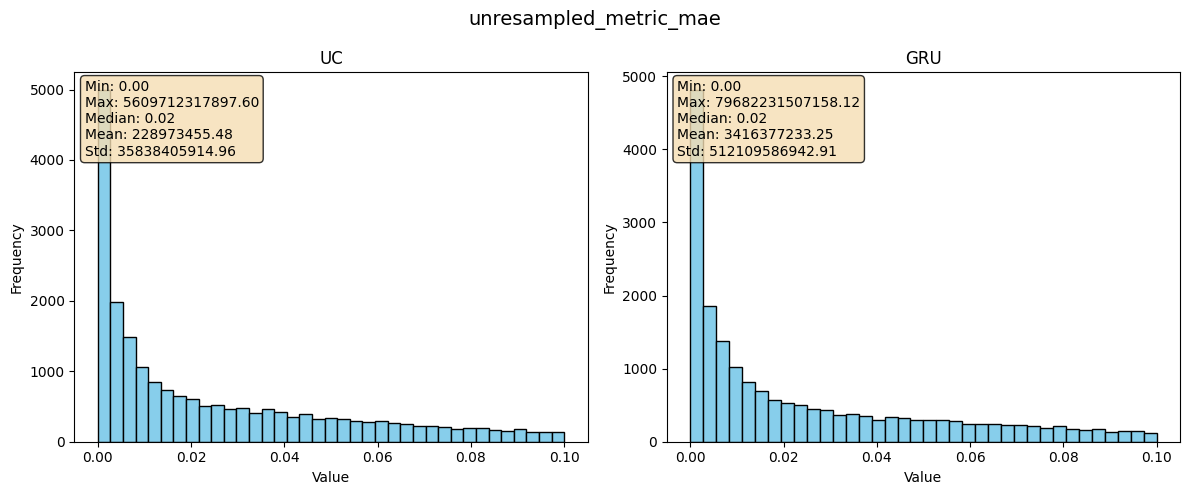

In [20]:
plot_two_histograms_with_stats(summary_df_uc, summary_df_gru, 'unresampled_metric_mae', x_range=(0, 0.1))

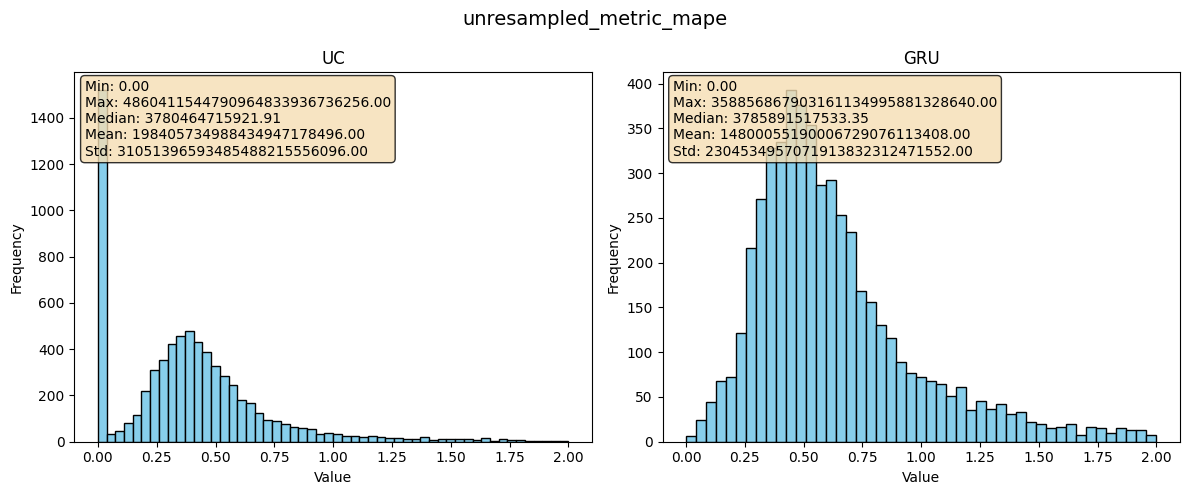

In [21]:
plot_two_histograms_with_stats(summary_df_uc, summary_df_gru, 'unresampled_metric_mape', x_range=(0, 2))

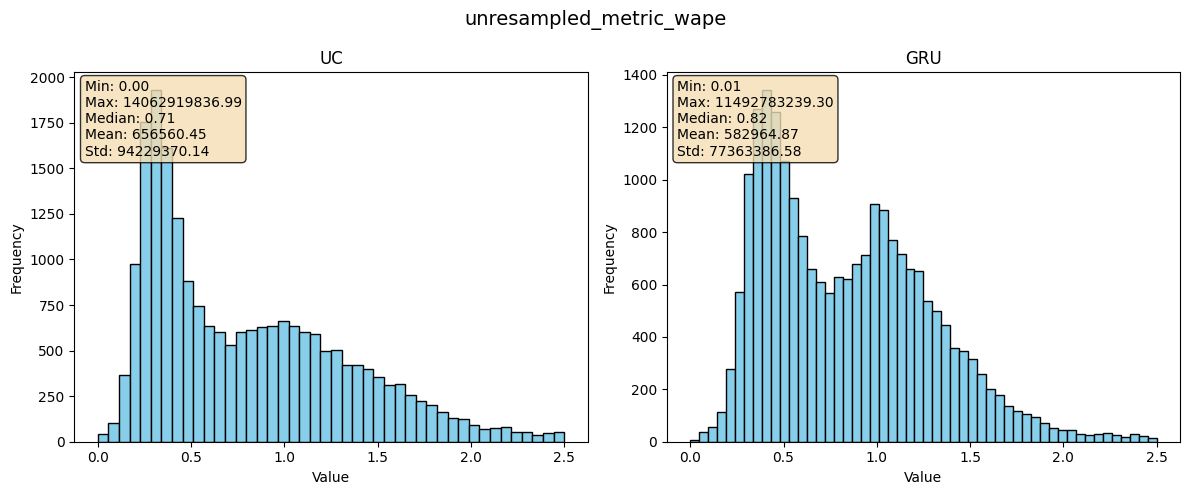

In [22]:
plot_two_histograms_with_stats(summary_df_uc, summary_df_gru, 'unresampled_metric_wape', x_range=(0, 2.5))

In [23]:
csv_files = ["./state_space_models/results/merged_final_thesis.csv",
             "./gru_predictor/results/merged_final_thesis.csv"]

model_names = ["UC", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=False, exclude_high_mae=False)
display_selected_metrics(
    summary,
    metrics=[
        "train_train_time_seconds",
        "prediction_time_seconds",
        "unresampled_metric_mae",
        #"unresampled_metric_mape",
        "unresampled_metric_wape",
        "number_of_anomalies",
    ],
    model_names=["UC", "GRU"],
)

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 24500 successful runs from ./state_space_models/results/merged_final_thesis.csv
✓ Loaded 24247 successful runs from ./gru_predictor/results/merged_final_thesis.csv
--------------------------------------------------------------------------------
Common filenames across all models (successful + converged): 24215
  UC: 24215 rows after filename intersection
  GRU: 24215 rows after filename intersection
--------------------------------------------------------------------------------


,Metric,UC,GRU
0,train_train_time_seconds,0.8164 ± 0.5024 | 0.6651,12.9234 ± 12.2160 | 9.0397
1,prediction_time_seconds,0.0076 ± 0.0041 | 0.0064,0.7472 ± 0.9600 | 0.4688
2,unresampled_metric_mae,231668373.2876 ± 36049425907.7155 | 0.0216,3420891958.4721 ± 512458416805.8008 | 0.0245
3,unresampled_metric_wape,663973.2461 ± 94761946.4221 | 0.6978,583768.8182 ± 77418431.7681 | 0.8221
4,number_of_anomalies,3.3263 ± 3.2277 | 3.0000,9.0058 ± 11.4045 | 8.0000


In [24]:
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

In [25]:
metric = 'unresampled_metric_wape'
comparator = '>'
value = 1

df_candidates = get_candidates(
    summary_df_uc,
    params=[
        #{"name": "converged_train", "value": True, "comparator": "=="},
        #{"name": "converged_second", "value": True, "comparator": "=="},
        #{"name": "status", "value": "success", "comparator": "=="},
        {"name": metric, "value": value, "comparator": comparator},
    ]
)
    
candidate_sensors = df_candidates['filename'].tolist()
print(f"Number of files with {metric} {comparator} {value}: {len(candidate_sensors)} out of {len(summary_df_uc)} total sensors.\nThat is {round((len(candidate_sensors)*100)/len(summary_df_uc),2)}%")


Number of files with unresampled_metric_wape > 1: 8014 out of 27603 total sensors.
That is 29.03%


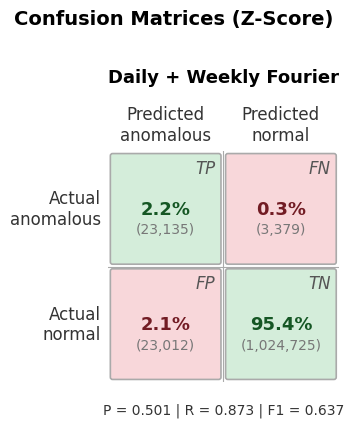

In [26]:
plot_confusion_matrices_clean(
    csv_files=['./state_space_models/results/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_test.csv'
        ],
    model_names=["Daily + Weekly Fourier"],
    only_converged=False,
)

- model jen na nektere sensory, najit prah pro ktere modely se to nehodi
- zkusit jine styly detekce (rozsirit horizont detekce)
- vytestovat vice typu anomalii (uniku)

- poslat diplomku
- vstup jedna hodnota
